In [27]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [28]:
data = pd.read_csv('ToyotaCorolla - MLR.csv')

In [29]:
data

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [4]:
data.shape

(1436, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
data.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [30]:
data.rename(columns={
    'Age_08_04':'Age'}, inplace=True)
data.head()

,Price,Age,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


### EDA - Exploratory data analysis

In [ ]:
#since there are too many columns the vizuation becomes difficult so lets take a few colums only
sns.pairplot(
    data,
    vars=['Age','KM','HP','cc','Weight'],
    hue='Fuel_Type',
    diag_kind='kde'
)

plt.show()


In [9]:
#finding the correlation between the features
corr = data.corr(numeric_only=True)
corr

,Price,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age,-0.876590,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,NaN,0.020613,1.000000


In [ ]:
sns.heatmap(corr, cmap='viridis',annot=True, fmt='0.2f')
plt.show()

# Conclusion - There are no strong correlation between the features . The features are independent of each other.

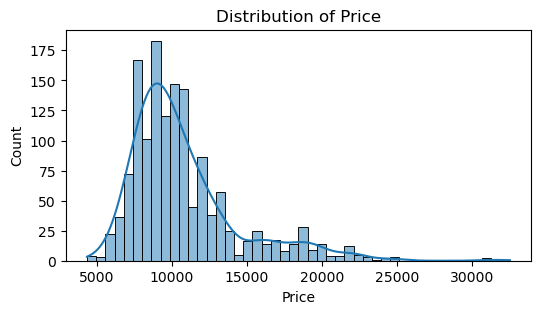

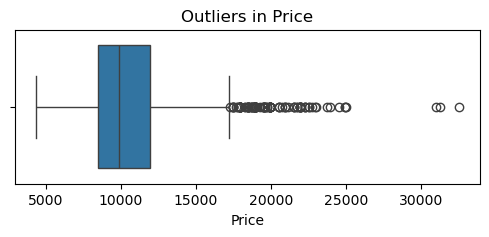

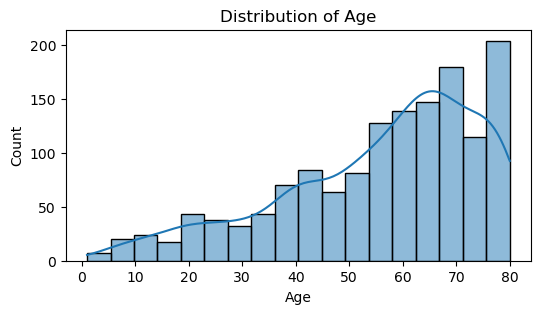

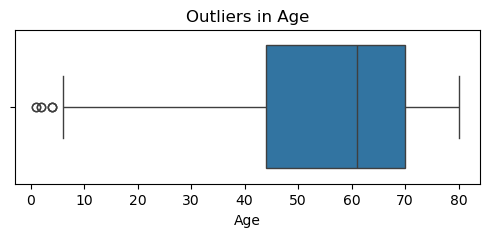

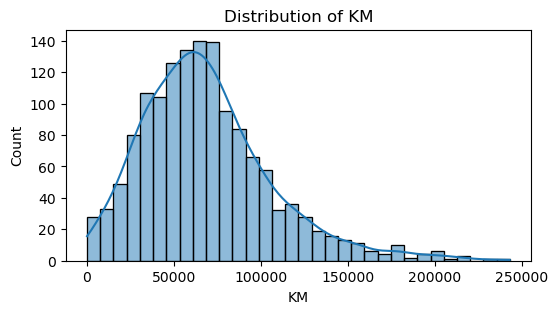

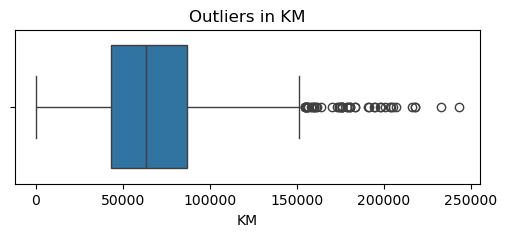

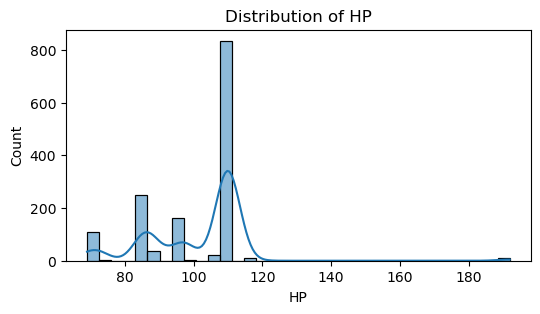

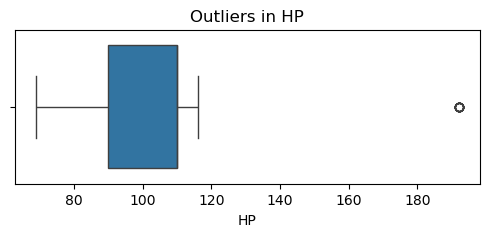

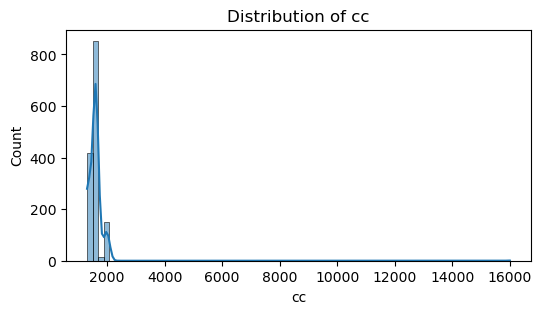

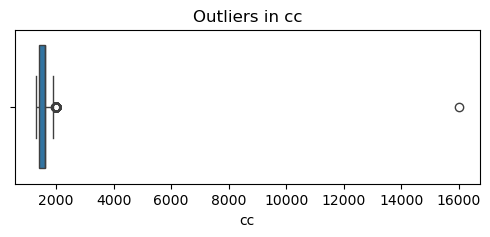

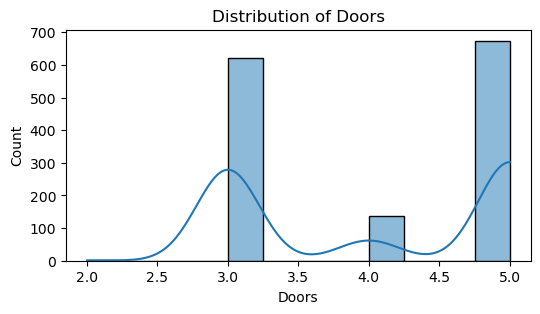

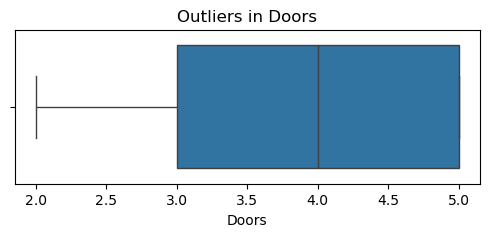

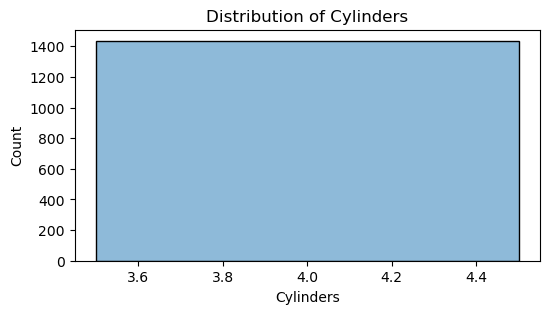

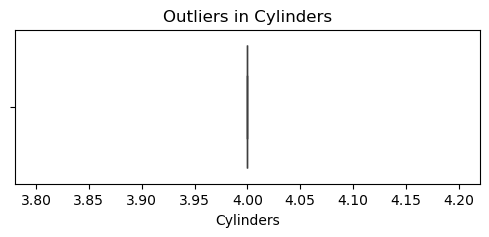

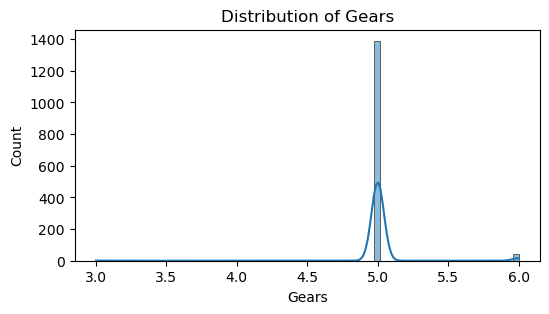

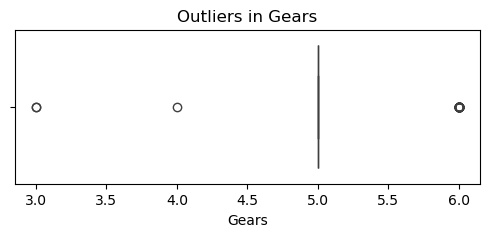

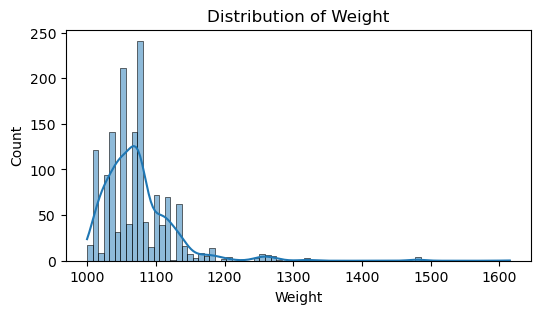

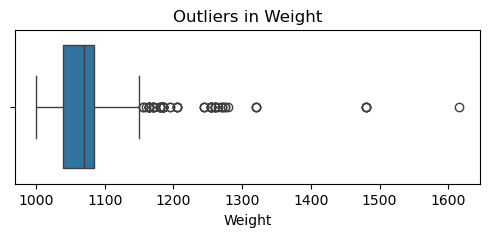

In [11]:
num_cols = ['Price','Age','KM','HP','cc','Doors','Cylinders','Gears','Weight']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(6,2))
    sns.boxplot(x=data[col])
    plt.title(f'Outliers in {col}')
    plt.show()

### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import*
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
data.columns

Index(['Price', 'Age', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [14]:
X=data[['Age', 'KM', 'HP', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight','Automatic']]
y=data['Price']

In [15]:
X.head()

,Age,KM,HP,cc,Doors,Cylinders,Gears,Weight,Automatic
0,23,46986,90,2000,3,4,5,1165,0
1,23,72937,90,2000,3,4,5,1165,0
2,24,41711,90,2000,3,4,5,1165,0
3,26,48000,90,2000,3,4,5,1165,0
4,30,38500,90,2000,3,4,5,1170,0


In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((1148, 9), (288, 9), (1148,), (288,))

### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [17]:
#model 1
features_m1 = ['Age', 'KM', 'HP', 'Weight']

#train the model
model1 = LinearRegression()

#predict using the model
model1.fit(X_train[features_m1], y_train)

y_pred1 = model1.predict(X_test[features_m1])
print("Model 1 R²:", r2_score(y_test, y_pred1))

coef_m1 = pd.DataFrame({
    'Feature': features_m1,
    'Coefficient': model1.coef_
})
coef_m1


Model 1 R²: 0.8506068681500583


,Feature,Coefficient
0,Age,-120.025405
1,KM,-0.020233
2,HP,29.052170
3,Weight,19.769066


In [18]:
#model 2
features_m2 = ['Age', 'KM', 'HP', 'Weight', 'cc', 'Automatic']

#train the model
model2 = LinearRegression()
model2.fit(X_train[features_m2], y_train)

#predict using the model
y_pred2 = model2.predict(X_test[features_m2])
print("Model 2 R²:", r2_score(y_test, y_pred2))

pd.DataFrame({
    'Feature': features_m2,
    'Coefficient': model2.coef_
})


Model 2 R²: 0.8509807795757858


,Feature,Coefficient
0,Age,-120.738145
1,KM,-0.019732
2,HP,29.346162
3,Weight,19.893373
4,cc,-0.112148
5,Automatic,311.554825


In [19]:
#model 3
model3 = LinearRegression()
#train the model
model3.fit(X_train, y_train)

#predict using the model
y_pred3 = model3.predict(X_test)
print("Model 3 R²:", r2_score(y_test, y_pred3))

coef_m3 = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model3.coef_
}).sort_values(by='Coefficient', ascending=False)

coef_m3


Model 3 R²: 0.8523452141908858


,Feature,Coefficient
6,Gears,6.264184e+02
8,Automatic,3.712087e+02
2,HP,2.742911e+01
7,Weight,1.984314e+01
4,Doors,7.535468e+00
5,Cylinders,-8.526513e-13
1,KM,-1.998627e-02
3,cc,-1.135136e-01
0,Age,-1.207831e+02


### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
#building the model
model = LinearRegression()   

In [22]:
#train the model
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
#predict using the model on training data
yhat_train = model.predict(X_train)

#metric calculation of training data
mse_tr = np.round(mean_squared_error(y_train,yhat_train))
rmse_tr = np.round(np.sqrt(mse_tr))
r2_tr = np.round(r2_score(y_train,yhat_train),2)

In [24]:
print(f'MSE: {mse_tr} \nRMSE: {rmse_tr} \nR_Squared: {r2_tr}' )

MSE: 1755825.0 
RMSE: 1325.0 
R_Squared: 0.87


In [25]:
# predict on testing data
yhat_test = model.predict(X_test)

#metric calculation on testing data
mse_ts = np.round(mean_squared_error(y_test,yhat_test))
rmse_ts = np.round(np.sqrt(mse_ts))
r2_ts = np.round(r2_score(y_test,yhat_test),2)
print(f'MSE: {mse_ts} \nRMSE: {rmse_ts} \nR_Squared: {r2_ts}' )

MSE: 1970127.0 
RMSE: 1404.0 
R_Squared: 0.85


#### The r-squared value for both training and testing data is 85 and above which indicates that it performs well on both training and testing data

### Conclusion- The model perform well on testing data and training data and is a correct fit. 

### Interview Questions:



#### 1.What is Normalization & Standardization and how is it helpful?
#### Ans : Normalization and standardization and two scaling techniques which are used and their is a large numerical difference between two parameters which makes the parameters with lower values less significant for comparing. In such cases we either standardize the data which brings the all the numerical data from -3 to +3 range or we use normalization which brings data from -1 to +1 range which makes the data to a same range fit for further analysis 

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?
##### Ans: Multicollinearity occurs when two or more independent variables in a multiple linear regression model are highly correlated, which can make coefficient estimates unstable and hard to interpret. The following techniques are commonly used to detect and address multicollinearity:
##### Variance Inflation Factor (VIF) – Identifies variables causing multicollinearity.
##### Principal Component Analysis (PCA) – Converts correlated predictors into uncorrelated components.
##### Ridge Regression – Shrinks coefficients to reduce multicollinearity impact.
##### Lasso Regression – Performs coefficient shrinkage and variable selection.